In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy 

data_paths = Path(r"C:\my_stuff\Capstone\data_analysis\05\14-22-02_data.csv")

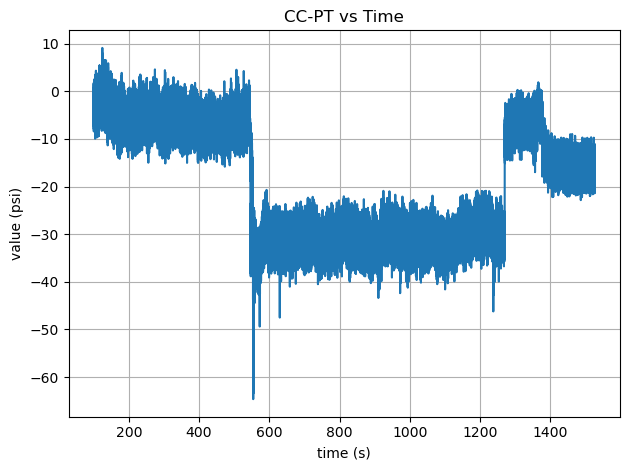

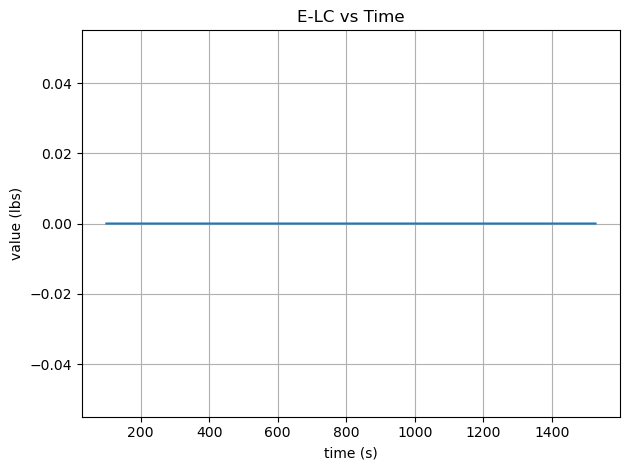

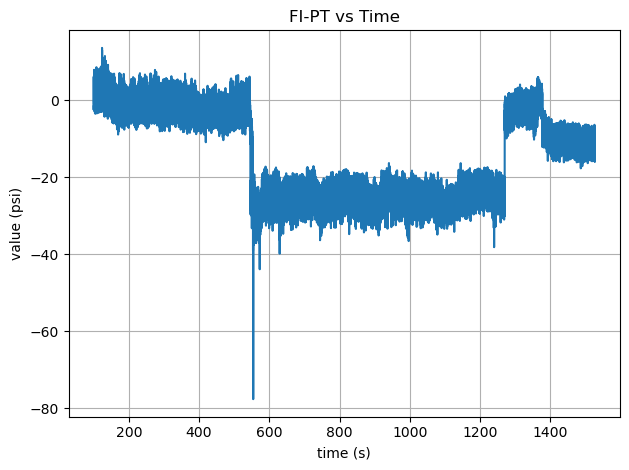

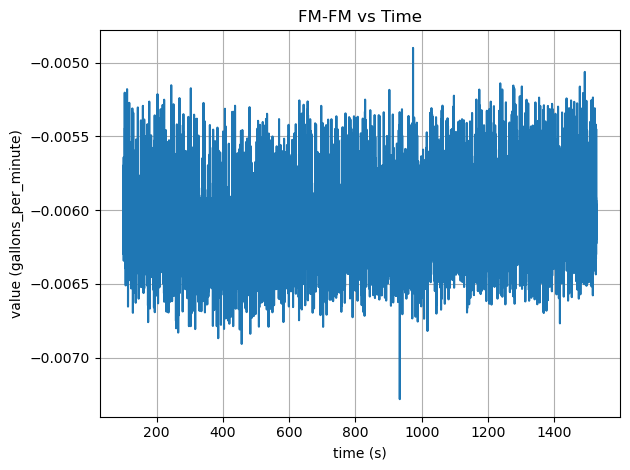

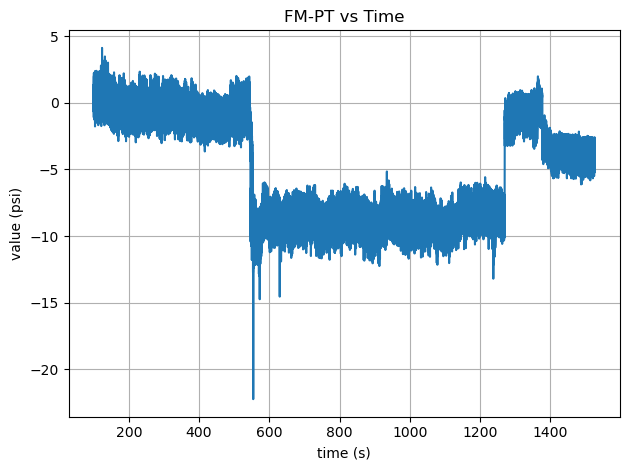

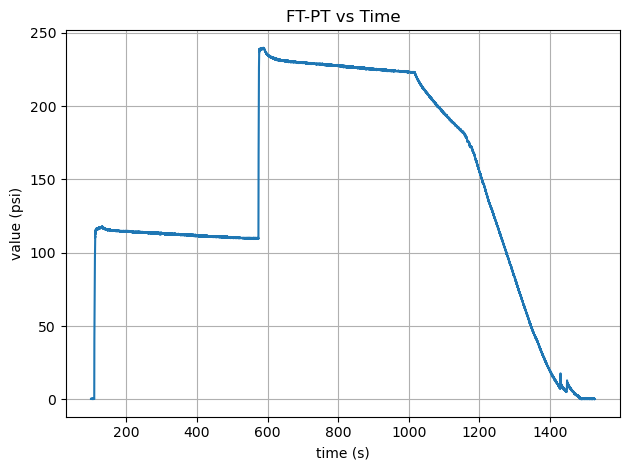

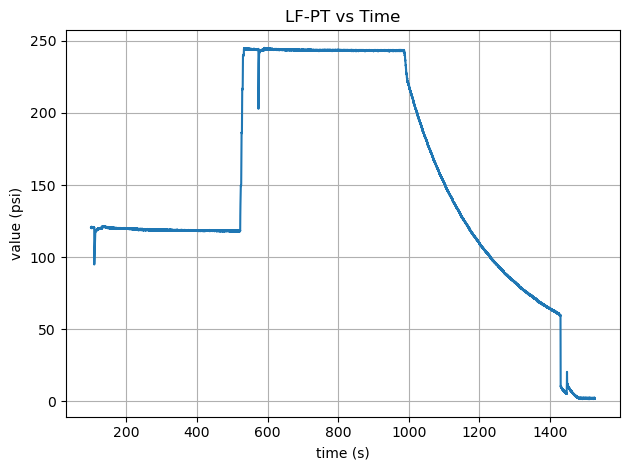

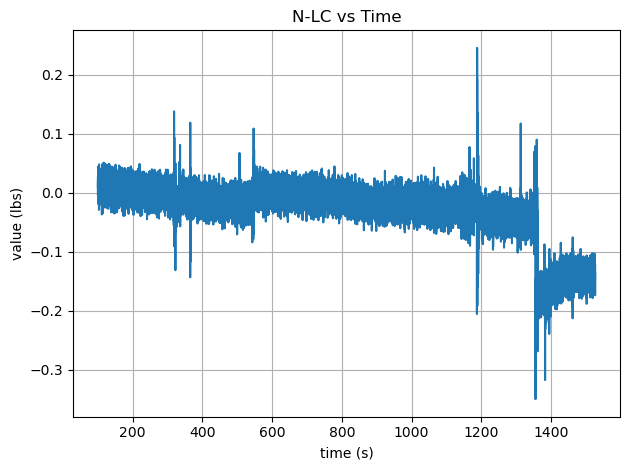

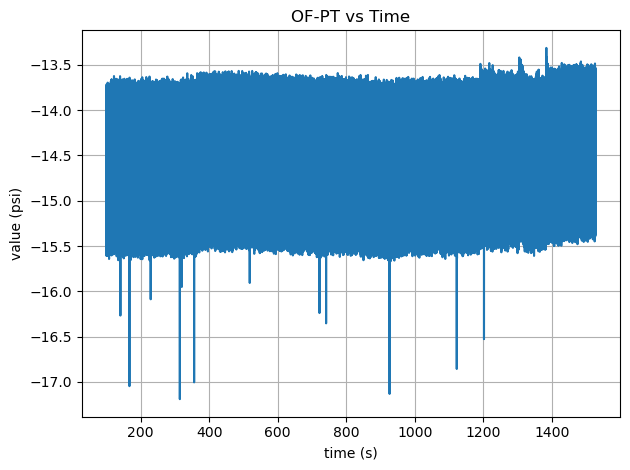

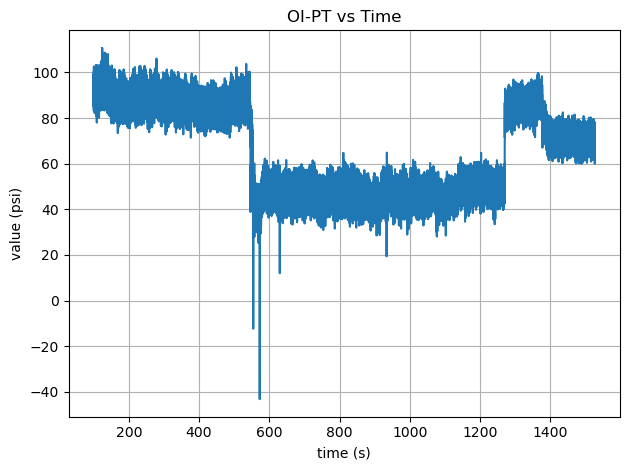

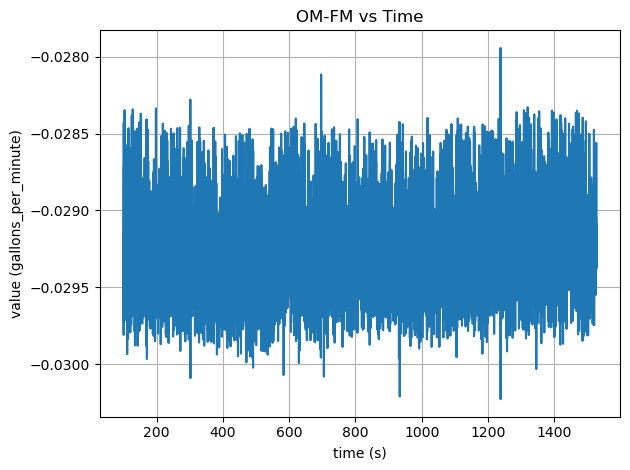

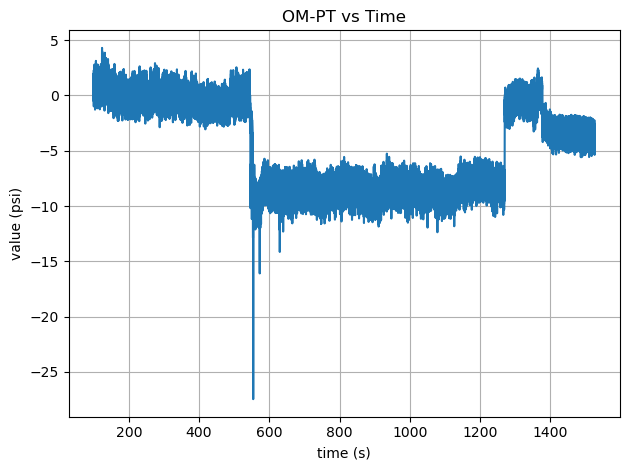

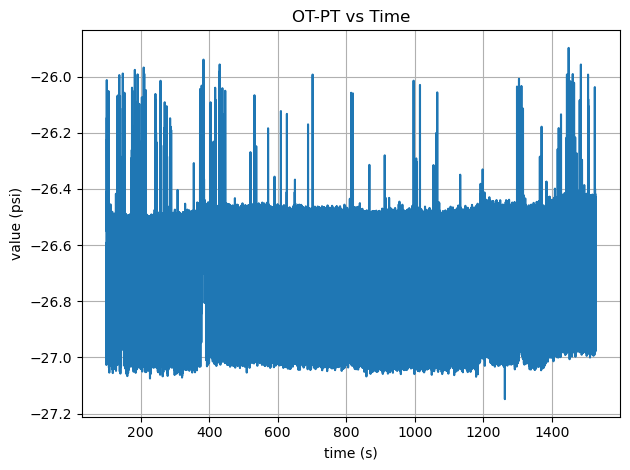

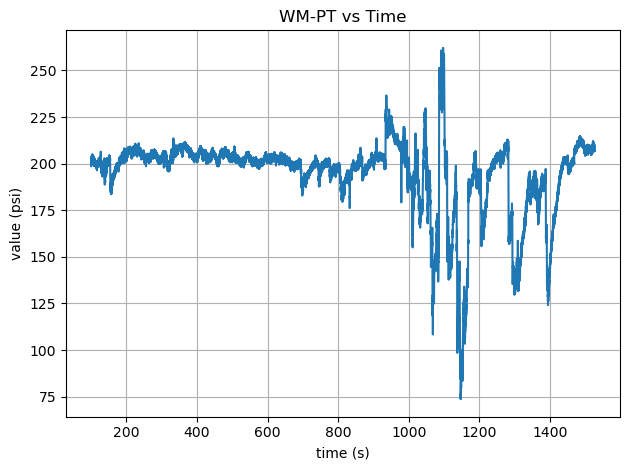

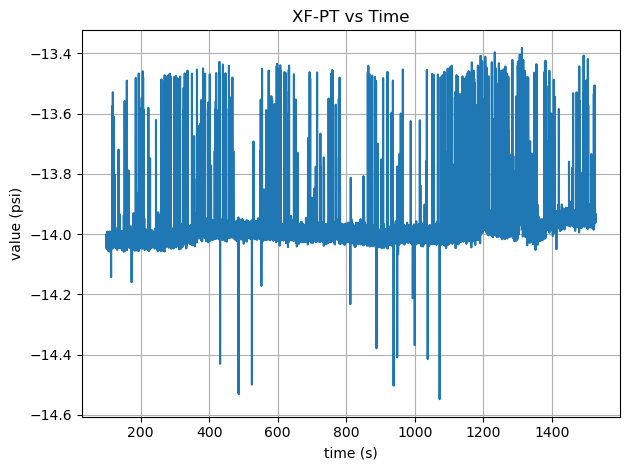

In [4]:
df = pd.read_csv(data_paths, header=0)
data_matrix = df.to_numpy()

df["t_rel"] = df.t_wall - df.t_wall.min()

t, value, raw_value, voltage, units, type = {}, {}, {}, {}, {}, {}
truncated_series = {}
sampling_rows = []
dt = []

plt.figure()
for name, g in df.groupby("sensor_name"):
    name = name.strip()
    g = g.sort_values("t_rel")
    t[name] = g.t_rel.to_numpy()
    value[name] = g.value.to_numpy()
    units[name] = g.units.iloc[0]
    type[name] = g.sensor_kind.iloc[0]
    
    mask = (t[name] > 100) 
    # mask = (t[name] > 4475) & (t[name] < 4525)
    t[name] = t[name][mask]
    value[name] = value[name][mask]

    if len(t[name]) == 0:
        continue

    truncated_series[name] = pd.Series(value[name], index=t[name], name=name)

    if len(t[name]) > 1:
        dt_sensor = np.diff(t[name])
        mean_dt = dt_sensor.mean()
        sampling_rate_hz = 1.0 / mean_dt if mean_dt > 0 else np.nan
    else:
        mean_dt = np.nan
        sampling_rate_hz = np.nan

    sampling_rows.append({
        "sensor_name": name,
        "sensor_kind": type[name],
        "units": units[name],
        "sample_count": len(t[name]),
        "mean_dt_s": mean_dt,
        "sampling_rate_hz": sampling_rate_hz,
    })

    plt.plot(t[name], value[name], label=name)
    plt.xlabel("time (s)")
    plt.ylabel(f"value ({units[name]})")
    # if name == "OM-FM":
    #     plt.ylim(0.8, 1.2)

    plt.title(f"{name} vs Time")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# truncated_df = pd.concat(truncated_series.values(), axis=1).sort_index()
# truncated_df.index.name = "time_s"
# truncated_df = truncated_df.reset_index()
# output_path = data_paths[1].with_name(f"{data_paths[1].stem}_truncated_wide.csv")
# truncated_df.to_csv(output_path, index=False)
# print(f"Saved truncated data to {output_path}")

# sampling_rate_df = pd.DataFrame(sampling_rows).sort_values("sensor_name").reset_index(drop=True)
# sampling_rate_path = data_paths[1].with_name(f"{data_paths[1].stem}_sampling_rates.csv")
# sampling_rate_df.to_csv(sampling_rate_path, index=False)
# print(f"Saved sampling rates to {sampling_rate_path}")

# display(sampling_rate_df)
# truncated_df.head()